#Model A

##Configuration

In [1]:
INPUT_PATH = '/content/seed_lhs_300.csv'

N_POOL     = 200_000
FOS_MIN, FOS_MAX = 0.5, 6.0      # censored target band
N_BINS     = 15                   # bin width ≈ 0.367
Q_TRAIN, Q_TEST = 20, 10          # 15×20=300 train, 15×10=150 test
N_LHS      = 300
SEED       = 42

RANGES = {                        # wide domain, identical to the generation
    'angle': (10.0, 65.0),
    'phi':   (5.0,  40.0),
    'c':     (1.0,  75.0),
    'gamma': (14.0, 22.0),
    'H':     (1.0,  25.0),
}
PARAMS   = ['angle', 'phi', 'c', 'gamma', 'H']
FEATURES = ['H', 'angle', 'phi', 'c', 'gamma', 'gamma_H_c']

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import qmc

rng = np.random.default_rng(SEED)

##Data + preliminary model on log(FOS)

In [2]:
data = pd.read_csv(INPUT_PATH)
if 'excluded' in data.columns:
    data = data[data['excluded'].fillna('').astype(str).str.strip() == '']
data = data[data['FOS'].notna()].reset_index(drop=True)
data['gamma_H_c'] = (data['gamma'] * data['H']) / data['c']
print(f'Valid rows for training: {len(data)}')

rf = RandomForestRegressor(n_estimators=500, oob_score=True,
                           random_state=SEED, n_jobs=-1)
rf.fit(data[FEATURES], np.log(data['FOS']))
print(f'OOB R² (on log-FOS): {rf.oob_score_:.4f}')


Valid rows for training: 300
OOB R² (on log-FOS): 0.9596


##Honest out-of-fold evaluation

In [3]:
from sklearn.model_selection import KFold, cross_val_predict
from scipy.stats import spearmanr

oof = np.exp(cross_val_predict(
    RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1),
    data[FEATURES], np.log(data['FOS']),
    cv=KFold(5, shuffle=True, random_state=SEED)))

y = data['FOS'].values
print(f'Global OOF RMSE: {np.sqrt(np.mean((oof-y)**2)):.3f} | '
      f'Spearman: {spearmanr(oof, y).statistic:.4f}')
m = (y >= FOS_MIN) & (y <= FOS_MAX)
print(f'OOF RMSE in band [{FOS_MIN}, {FOS_MAX}]: '
      f'{np.sqrt(np.mean((oof[m]-y[m])**2)):.3f} (n={m.sum()})')

zones = [('FOS < 1.0', y < 1.0), ('1.0-1.5', (y >= 1.0) & (y < 1.5)),
         ('1.5-3.0', (y >= 1.5) & (y < 3.0)), ('3.0-6.0', (y >= 3.0) & (y < 6.0)),
         ('FOS > 6', y >= 6.0)]
for zn, zm in zones:
    e = oof[zm] - y[zm]
    print(f'  {zn:<10} n={zm.sum():3d}  RMSE={np.sqrt(np.mean(e**2)):6.3f}  '
          f'MAE={np.abs(e).mean():6.3f}')

Global OOF RMSE: 0.786 | Spearman: 0.9749
OOF RMSE in band [0.5, 6.0]: 0.378 (n=272)
  FOS < 1.0  n= 35  RMSE= 0.171  MAE= 0.139
  1.0-1.5    n= 44  RMSE= 0.172  MAE= 0.135
  1.5-3.0    n=119  RMSE= 0.257  MAE= 0.196
  3.0-6.0    n= 82  RMSE= 0.594  MAE= 0.480
  FOS > 6    n= 20  RMSE= 2.705  MAE= 2.250


##Candidate pool, predictions, bins on the censored band

In [4]:
pool = pd.DataFrame({k: rng.uniform(lo, hi, N_POOL) for k, (lo, hi) in RANGES.items()})
pool['gamma_H_c'] = (pool['gamma'] * pool['H']) / pool['c']
pool['FOS_pred'] = np.exp(rf.predict(pool[FEATURES]))

edges = np.linspace(FOS_MIN, FOS_MAX, N_BINS + 1)
in_band = pool[(pool['FOS_pred'] >= FOS_MIN) & (pool['FOS_pred'] <= FOS_MAX)]
counts = pd.cut(in_band['FOS_pred'], edges).value_counts().sort_index()
print(f'Predicted FOS in pool: [{pool.FOS_pred.min():.3f}, {pool.FOS_pred.max():.3f}]')
print(f'Candidates in band [{FOS_MIN}, {FOS_MAX}]: {len(in_band)} of {len(pool)}')
print(counts.to_string())

deficit = counts[counts < (Q_TRAIN + Q_TEST)]
if len(deficit):
    raise RuntimeError(f'Insufficient bins:\n{deficit}\n→ increase N_POOL.')
print('\nAll bins have enough candidates ✔')


Predicted FOS in pool: [0.243, 20.069]
Candidates in band [0.5, 6.0]: 185738 of 200000
FOS_pred
(0.5, 0.867]      12218
(0.867, 1.233]    23951
(1.233, 1.6]      25660
(1.6, 1.967]      25314
(1.967, 2.333]    21855
(2.333, 2.7]      15515
(2.7, 3.067]      11437
(3.067, 3.433]    10428
(3.433, 3.8]      11074
(3.8, 4.167]       7650
(4.167, 4.533]     5245
(4.533, 4.9]       4546
(4.9, 5.267]       4651
(5.267, 5.633]     3948
(5.633, 6.0]       2246

All bins have enough candidates ✔


##Stratified selection with max-min diversification

In [5]:
mu, sd = pool[PARAMS].mean(), pool[PARAMS].std()

def greedy_maxmin(Xs, k, rng):
    n = len(Xs)
    if k >= n:
        return np.arange(n)
    sel = [int(rng.integers(n))]
    dmin = np.linalg.norm(Xs - Xs[sel[0]], axis=1)
    for _ in range(k - 1):
        nxt = int(dmin.argmax())
        sel.append(nxt)
        dmin = np.minimum(dmin, np.linalg.norm(Xs - Xs[nxt], axis=1))
    return np.array(sel)

train_idx, test_idx = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    cand = pool[(pool['FOS_pred'] > lo) & (pool['FOS_pred'] <= hi)]
    Xs = ((cand[PARAMS] - mu) / sd).values
    sel = cand.index.values[greedy_maxmin(Xs, Q_TRAIN + Q_TEST, rng)]
    perm = rng.permutation(len(sel))
    train_idx += list(sel[perm[:Q_TRAIN]])
    test_idx  += list(sel[perm[Q_TRAIN:Q_TRAIN + Q_TEST]])

set_uniform = pool.loc[train_idx, PARAMS + ['FOS_pred']].reset_index(drop=True)
set_test    = pool.loc[test_idx,  PARAMS + ['FOS_pred']].reset_index(drop=True)
assert len(set(train_idx) & set(test_idx)) == 0
print(f'set_uniform: {len(set_uniform)} | set_test: {len(set_test)} | disjoint ✔')

set_uniform: 300 | set_test: 150 | disjoint ✔


##LHS set (conventional budget extension, arm B)

In [6]:
sampler = qmc.LatinHypercube(d=len(PARAMS), seed=SEED)
lo = np.array([RANGES[p][0] for p in PARAMS])
hi = np.array([RANGES[p][1] for p in PARAMS])
set_lhs = pd.DataFrame(qmc.scale(sampler.random(N_LHS), lo, hi), columns=PARAMS)
print(f'set_lhs: {len(set_lhs)} combinations')

set_lhs: 300 combinations


##Preview

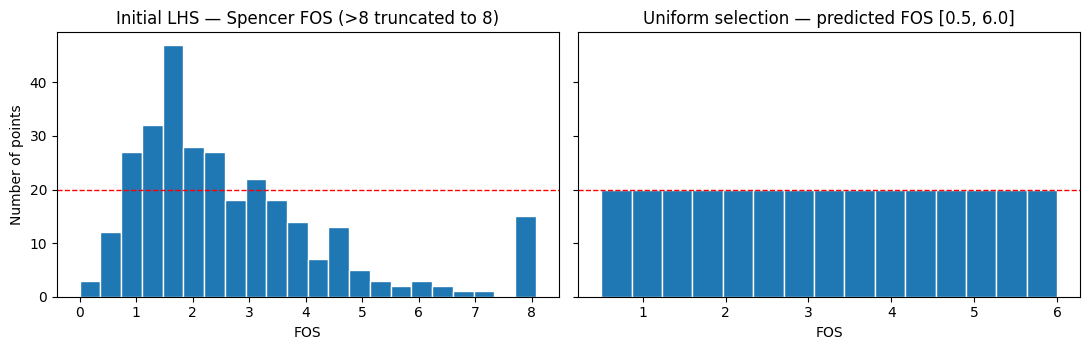

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
ax[0].hist(data['FOS'].clip(upper=8), bins=np.arange(0, 8.1, 0.367), edgecolor='white')
ax[0].set_title('Initial LHS — Spencer FOS (>8 truncated to 8)')
ax[1].hist(set_uniform['FOS_pred'], bins=edges, edgecolor='white')
ax[1].set_title(f'Uniform selection — predicted FOS [{FOS_MIN}, {FOS_MAX}]')
for a in ax:
    a.set_xlabel('FOS'); a.axhline(Q_TRAIN, ls='--', c='red', lw=1)
ax[0].set_ylabel('Number of points')
plt.tight_layout(); plt.show()

##Export

In [ ]:
set_uniform.to_csv('set_uniform_300.csv', index=False)
set_test.to_csv('set_test_150.csv', index=False)
set_lhs.to_csv('set_lhs_300.csv', index=False)

def as_array_literal(df, name):
    lines = [f'# Format: [angle, phi, c, gamma, H]  ({len(df)} combinations)', f'{name} = [']
    for _, r in df.iterrows():
        lines.append(f"    [{r['angle']:.6f}, {r['phi']:.6f}, {r['c']:.6f}, "
                     f"{r['gamma']:.6f}, {r['H']:.6f}],")
    lines.append(']\n')
    return '\n'.join(lines)

with open('hyrcan_arrays.py', 'w') as f:
    f.write('# Arrays for Hyrcan batch — Spencer, wide domain\n\n')
    f.write(as_array_literal(set_uniform, 'uniform_train_300'))
    f.write('\n')
    f.write(as_array_literal(set_test, 'test_150'))
    f.write('\n')
    f.write(as_array_literal(set_lhs, 'lhs_300'))

print('Written: set_uniform_300.csv, set_test_150.csv, set_lhs_300.csv, hyrcan_arrays.py')
try:
    from google.colab import files
    for fn in ['set_uniform_300.csv', 'set_test_150.csv', 'set_lhs_300.csv', 'hyrcan_arrays.py']:
        files.download(fn)
except ImportError:
    pass

#Models B&C

##Configuration and data loading

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from scipy.stats import spearmanr
import os

SEED       = 42
LOG_TARGET = True            # consistent with the preliminary model
FOS_MIN, FOS_MAX = 0.5, 6.0  # target band

PATH_INITIAL      = '/content/seed_lhs_300.csv'
PATH_UNIFORM      = '/content/surrogate_guided_300.csv'
PATH_LHS          = '/content/lhs_continued_300.csv'
PATH_TEST         = '/content/test_uniform_150.csv'

PARAMS   = ['angle', 'phi', 'c', 'gamma', 'H']
FEATURES = ['H', 'angle', 'phi', 'c', 'gamma', 'gamma_H_c']

def load_results(path):
    """Load a Hyrcan results CSV, filter excluded/NaN, add feature."""
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if 'excluded' in df.columns:
        df = df[df['excluded'].fillna('').astype(str).str.strip() == '']
    df = df[df['FOS'].notna()].reset_index(drop=True)
    df['gamma_H_c'] = (df['gamma'] * df['H']) / df['c']
    return df

initial = load_results(PATH_INITIAL)
uniform = load_results(PATH_UNIFORM)
lhs     = load_results(PATH_LHS)
test    = load_results(PATH_TEST)

print(f'initial: {len(initial)} | uniform: {len(uniform)}')
print(f'lhs:     {"missing" if lhs is None else len(lhs)}')
print(f'test:    {"missing" if test is None else len(test)}')

at_b = (uniform['At_Boundary'].astype(str).str.lower() == 'true').sum()
print(f'\nuniform At_Boundary=True (needs fixing before training!): {at_b}')


initial: 300 | uniform: 300
lhs:     300
test:    150

uniform At_Boundary=True (needs fixing before training!): 0


##Diagnostic: realized vs. predicted FOS distribution (paper result)

Realized in band [0.5, 6.0]: 259/300 | below band: 5 | above band: 36
Realized FOS: [0.255, 11.466]


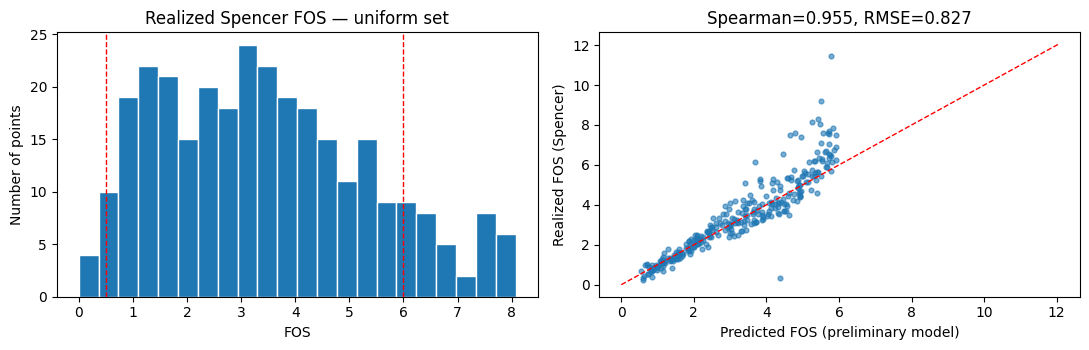

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

bins_band = np.linspace(FOS_MIN, FOS_MAX, 16)
ax[0].hist(uniform['FOS'].clip(upper=8), bins=np.arange(0, 8.3, 0.367),
           edgecolor='white')
ax[0].axvline(FOS_MIN, ls='--', c='red', lw=1)
ax[0].axvline(FOS_MAX, ls='--', c='red', lw=1)
ax[0].set_title('Realized Spencer FOS — uniform set')
ax[0].set_xlabel('FOS'); ax[0].set_ylabel('Number of points')

in_band  = ((uniform['FOS'] >= FOS_MIN) & (uniform['FOS'] <= FOS_MAX)).sum()
below    = (uniform['FOS'] < FOS_MIN).sum()
above    = (uniform['FOS'] > FOS_MAX).sum()
print(f'Realized in band [{FOS_MIN}, {FOS_MAX}]: {in_band}/{len(uniform)} '
      f'| below band: {below} | above band: {above}')
print(f'Realized FOS: [{uniform.FOS.min():.3f}, {uniform.FOS.max():.3f}]')

# scatter predicted vs realized (uses set_uniform from the Model A run, in memory)
if 'set_uniform' in globals() and len(set_uniform) == len(uniform):
    pred, real = set_uniform['FOS_pred'].values, uniform['FOS'].values
    ax[1].scatter(pred, real, s=12, alpha=0.6)
    lim = [0, max(real.max(), pred.max()) * 1.05]
    ax[1].plot(lim, lim, 'r--', lw=1)
    ax[1].set_xlabel('Predicted FOS (preliminary model)')
    ax[1].set_ylabel('Realized FOS (Spencer)')
    ax[1].set_title(f'Spearman={spearmanr(pred, real).statistic:.3f}, '
                    f'RMSE={np.sqrt(np.mean((pred-real)**2)):.3f}')
plt.tight_layout(); plt.show()


#Building the arms and training

In [25]:
def make_model():
    return RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1)

def fit(df):
    y = np.log(df['FOS']) if LOG_TARGET else df['FOS']
    return make_model().fit(df[FEATURES], y)

def predict(model, df):
    p = model.predict(df[FEATURES])
    return np.exp(p) if LOG_TARGET else p

ARMS = {
    'A  (LHS-300)':          initial,
    'C0 (uniform-300)':      uniform,
    'C  (LHS+uniform, 600)': pd.concat([initial, uniform], ignore_index=True),
}
if lhs is not None:
    ARMS['B  (LHS-600)'] = pd.concat([initial, lhs], ignore_index=True)

models = {}
for name, df in ARMS.items():
    models[name] = fit(df)
    print(f'{name}: trained on {len(df)} points')


A  (LHS-300): trained on 300 points
C0 (uniform-300): trained on 300 points
C  (LHS+uniform, 600): trained on 600 points
B  (LHS-600): trained on 600 points


##Sanity check: OOF on the training set itself

In [26]:
print('5-fold OOF on the training set itself (sanity check, NOT a paper metric):\n')
for name, df in ARMS.items():
    y = df['FOS'].values
    target = np.log(y) if LOG_TARGET else y
    oof = cross_val_predict(make_model(), df[FEATURES], target,
                            cv=KFold(5, shuffle=True, random_state=SEED))
    if LOG_TARGET:
        oof = np.exp(oof)
    m = (y >= FOS_MIN) & (y <= FOS_MAX)
    print(f'{name}: RMSE={np.sqrt(np.mean((oof-y)**2)):.3f} '
          f'| RMSE band={np.sqrt(np.mean((oof[m]-y[m])**2)):.3f} '
          f'| Spearman={spearmanr(oof, y).statistic:.4f}')


5-fold OOF on the training set itself (sanity check, NOT a paper metric):

A  (LHS-300): RMSE=0.786 | RMSE band=0.378 | Spearman=0.9749
C0 (uniform-300): RMSE=0.623 | RMSE band=0.393 | Spearman=0.9679
C  (LHS+uniform, 600): RMSE=0.577 | RMSE band=0.277 | Spearman=0.9828
B  (LHS-600): RMSE=0.298 | RMSE band=0.190 | Spearman=0.9934


##Evaluation on the test set

In [27]:
if test is None:
    print('results_test.csv missing — final evaluation runs after the test batch.')
else:
    y_test = test['FOS'].values
    zones = [('FOS < 1.0',  y_test < 1.0),
             ('1.0 - 1.3',  (y_test >= 1.0) & (y_test < 1.3)),
             ('1.3 - 3.0',  (y_test >= 1.3) & (y_test < 3.0)),
             ('3.0 - 6.0',  (y_test >= 3.0) & (y_test <= 6.0)),
             ('> 6.0',  y_test > 6.0)]

    print(f'Test set: {len(test)} points, FOS ∈ [{y_test.min():.2f}, {y_test.max():.2f}]\n')

    rows_global, rows_zone = [], []
    preds = {}
    for name, model in models.items():
        p = predict(model, test)
        preds[name] = p
        e = p - y_test
        rows_global.append({
            'model': name,
            'R2':   1 - np.sum(e**2) / np.sum((y_test - y_test.mean())**2),
            'RMSE': np.sqrt(np.mean(e**2)),
            'MAE':  np.abs(e).mean(),
            'bias': e.mean(),                       # >0 = non-conservative on average
            'max_err': np.abs(e).max(),
        })
        for zn, zm in zones:
            if zm.sum() == 0:
                continue
            ez = p[zm] - y_test[zm]
            rows_zone.append({
                'model': name, 'zone': zn, 'n': int(zm.sum()),
                'RMSE': np.sqrt(np.mean(ez**2)),
                'MAE':  np.abs(ez).mean(),
                'bias': ez.mean(),
            })

    print('── Global metrics ──')
    print(pd.DataFrame(rows_global).round(4).to_string(index=False))
    print('\n── Per-zone metrics ──')
    dz = pd.DataFrame(rows_zone).round(4)
    print(dz.pivot_table(index='zone', columns='model',
                         values='RMSE', sort=False).round(3).to_string())

    # minimax criterion: worst per-zone RMSE per model
    print('\n── Minimax (RMSE of the worst zone) ──')
    for name in models:
        worst = dz[dz['model'] == name]['RMSE'].max()
        print(f'  {name}: {worst:.3f}')

    # non-conservative errors at the FOS=1.0 threshold (false stable)
    print('\n── False stable: actual FOS < 1.0 predicted ≥ 1.0 ──')
    unstable = y_test < 1.0
    for name, p in preds.items():
        fs = int(((p >= 1.0) & unstable).sum())
        print(f'  {name}: {fs}/{int(unstable.sum())}')

Test set: 150 points, FOS ∈ [0.39, 10.63]

── Global metrics ──
                model     R2   RMSE    MAE    bias  max_err
         A  (LHS-300) 0.8427 0.7557 0.4757 -0.1734   4.7028
     C0 (uniform-300) 0.9358 0.4829 0.3103 -0.1178   3.0529
C  (LHS+uniform, 600) 0.9456 0.4442 0.2654 -0.1080   2.5901
         B  (LHS-600) 0.8495 0.7392 0.4557 -0.0986   4.6693

── Per-zone metrics ──
model      A  (LHS-300)  C0 (uniform-300)  C  (LHS+uniform, 600)  B  (LHS-600)
zone                                                                          
FOS < 1.0         0.171             0.226                  0.157         0.183
1.0 - 1.3         0.215             0.195                  0.180         0.229
1.3 - 3.0         0.283             0.193                  0.186         0.304
3.0 - 6.0         0.687             0.455                  0.468         0.703
> 6.0             1.872             1.138                  0.946         1.756

── Minimax (RMSE of the worst zone) ──
  A  (LHS-300): 1.8

##Paired Wilcoxon, multiplicative conformal, reporting details

In [30]:
from scipy.stats import wilcoxon

y_test = test['FOS'].values
band_m = (y_test >= FOS_MIN) & (y_test <= FOS_MAX)

# n per zone (was missing from the pivot — needed in the paper)
print('── n per zone (test-150) ──')
for zn, zm in zones:
    print(f'  {zn:<10} n={int(zm.sum())}')

# ── 1. Paired Wilcoxon signed-rank on absolute errors ─────────────────────────
print('\n── Wilcoxon signed-rank (absolute errors, paired) ──')
pairs = [('C  (LHS+uniform, 600)', 'B  (LHS-600)'),
         ('C  (LHS+uniform, 600)', 'A  (LHS-300)'),
         ('C0 (uniform-300)',      'B  (LHS-600)'),
         ('C  (LHS+uniform, 600)', 'C0 (uniform-300)')]
for m1, m2 in pairs:
    e1, e2 = np.abs(preds[m1] - y_test), np.abs(preds[m2] - y_test)
    for label, mask in [('global', np.ones(len(y_test), bool)), ('band', band_m)]:
        stat, p = wilcoxon(e1[mask], e2[mask])
        sign = '<' if e1[mask].mean() < e2[mask].mean() else '>'
        print(f'  {m1.split()[0]} {sign} {m2.split()[0]} ({label}): p={p:.2e}')

# ── 2. Multiplicative conformal (cross-conformal on log residuals, OOF) ───────
ALPHA = 0.10   # 90% intervals

print(f'\n── Conformal {int((1-ALPHA)*100)}%: FOS_pred ×/÷ exp(q) ──')
conformal_q = {}
for name, df in ARMS.items():
    y_tr = df['FOS'].values
    oof = cross_val_predict(make_model(), df[FEATURES], np.log(y_tr),
                            cv=KFold(5, shuffle=True, random_state=SEED))
    scores = np.abs(oof - np.log(y_tr))            # residuals on the log scale
    n = len(scores)
    q = np.quantile(scores, np.ceil((n+1)*(1-ALPHA))/n)   # finite-sample correction
    conformal_q[name] = q

    p = preds[name]
    lo, hi = p / np.exp(q), p * np.exp(q)
    cover      = ((y_test >= lo) & (y_test <= hi)).mean()
    cover_band = ((y_test[band_m] >= lo[band_m]) & (y_test[band_m] <= hi[band_m])).mean()
    width_band = (hi[band_m] - lo[band_m]).mean()

    print(f'  {name}: factor ×/÷{np.exp(q):.3f} | coverage global={cover:.1%} '
          f'band={cover_band:.1%} | mean band width={width_band:.3f}')

# ── 3. The 3 false-stable points and their conformal treatment ──────────────
print('\n── False-stable points (actual FOS < 1.0, predicted ≥ 1.0) ──')
name_c = 'C  (LHS+uniform, 600)'
fs_mask = (y_test < 1.0) & (preds[name_c] >= 1.0)
q = conformal_q[name_c]
for i in np.where(fs_mask)[0]:
    p = preds[name_c][i]
    lo = p / np.exp(q)
    flag = 'interval below 1.0 → flagged' if lo < 1.0 else 'interval above 1.0 → also missed by UQ'
    print(f'  actual FOS={y_test[i]:.3f}  predicted={p:.3f}  '
          f'interval=[{lo:.3f}, {p*np.exp(q):.3f}]  → {flag}')

── n per zone (test-150) ──
  FOS < 1.0  n=14
  1.0 - 1.3  n=7
  1.3 - 3.0  n=47
  3.0 - 6.0  n=68
  > 6.0      n=14

── Wilcoxon signed-rank (absolute errors, paired) ──
  C < B (global): p=5.38e-07
  C < B (band): p=4.59e-07
  C < A (global): p=3.99e-10
  C < A (band): p=1.07e-07
  C0 < B (global): p=1.56e-03
  C0 < B (band): p=1.66e-03
  C < C0 (global): p=2.92e-04
  C < C0 (band): p=3.90e-03

── Conformal 90%: FOS_pred ×/÷ exp(q) ──
  A  (LHS-300): factor ×/÷1.300 | coverage global=86.0% band=88.1% | mean band width=1.620
  C0 (uniform-300): factor ×/÷1.286 | coverage global=93.3% band=94.1% | mean band width=1.543
  C  (LHS+uniform, 600): factor ×/÷1.211 | coverage global=90.7% band=91.9% | mean band width=1.165
  B  (LHS-600): factor ×/÷1.120 | coverage global=55.3% band=57.8% | mean band width=0.703

── False-stable points (actual FOS < 1.0, predicted ≥ 1.0) ──
  actual FOS=0.954  predicted=1.175  interval=[0.970, 1.423]  → interval below 1.0 → flagged
  actual FOS=0.985  predic

##Learning curve via subsampling


LHS continued:
 budget  rmse_g  std_g  rmse_b  std_b
    100   1.088  0.137   0.833  0.138
    200   0.864  0.050   0.583  0.052
    300   0.756  0.000   0.521  0.000
    400   0.747  0.018   0.520  0.046
    500   0.749  0.024   0.525  0.055
    600   0.749  0.007   0.551  0.011

Surrogate-guided:
 budget  rmse_g  std_g  rmse_b  std_b
    100   1.088  0.137   0.833  0.138
    200   0.864  0.050   0.583  0.052
    300   0.756  0.000   0.521  0.000
    400   0.595  0.059   0.433  0.067
    500   0.468  0.033   0.368  0.044
    600   0.445  0.004   0.354  0.005


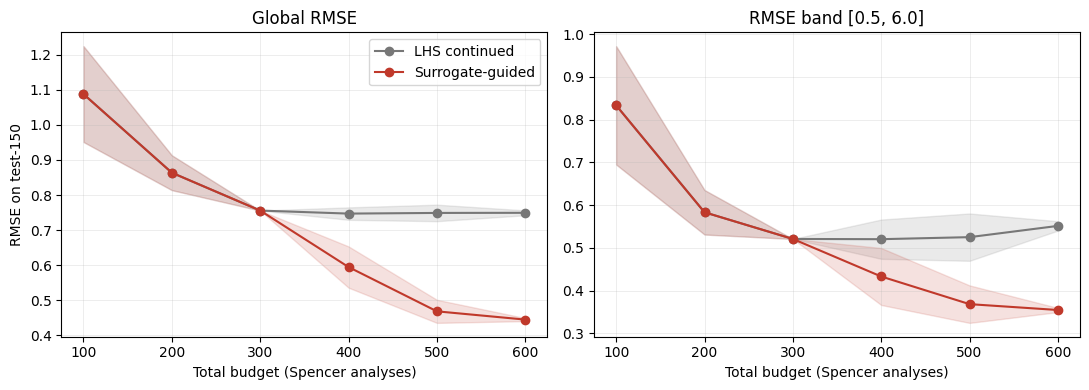

In [29]:
# Question: how does performance grow with budget, for each strategy?
# A and B are points on the SAME curve (LHS at 300 and 600) — treat them together.

BUDGETS_LHS     = [100, 200, 300, 400, 500, 600]   # from initial+lhs concatenated
BUDGETS_UNIFORM = [100, 200, 300, 400, 500, 600]   # from initial+uniform (C)
N_REPEATS       = 10                                # random subsamples per budget

pool_lhs = pd.concat([initial, lhs], ignore_index=True)      # 600 LHS
pool_C   = pd.concat([initial, uniform], ignore_index=True)  # 600 mixed

y_test  = test['FOS'].values
band_m  = (y_test >= FOS_MIN) & (y_test <= FOS_MAX)

def eval_subsample_(pool, budget, seed, fixed_seed_df=None):
    """Train on a subsample and return (rmse_global, rmse_band)."""
    rng_l = np.random.default_rng(seed)
    if fixed_seed_df is not None and budget > len(fixed_seed_df):
        # strategy C: full LHS seed + subsample from uniform
        extra = pool.iloc[len(fixed_seed_df):]
        take  = extra.iloc[rng_l.choice(len(extra), budget - len(fixed_seed_df),
                                        replace=False)]
        df = pd.concat([fixed_seed_df, take], ignore_index=True)
    else:
        df = pool.iloc[rng_l.choice(len(pool), budget, replace=False)]
    model = fit(df)
    p = predict(model, test)
    e = p - y_test
    return (np.sqrt(np.mean(e**2)), np.sqrt(np.mean(e[band_m]**2)))

def eval_subsample(pool_extra, budget, seed_rng, seed_df):
    """Real seed + subsample from the strategy's additional points."""
    rng_l = np.random.default_rng(seed_rng)
    if budget < len(seed_df):
        df = seed_df.iloc[rng_l.choice(len(seed_df), budget, replace=False)]
    elif budget == len(seed_df):
        df = seed_df
    else:
        take = pool_extra.iloc[rng_l.choice(len(pool_extra),
                                            budget - len(seed_df), replace=False)]
        df = pd.concat([seed_df, take], ignore_index=True)
    model = fit(df)
    p = predict(model, test)
    e = p - y_test
    return (np.sqrt(np.mean(e**2)), np.sqrt(np.mean(e[band_m]**2)))

curves = {}
for label, extra in [('LHS continued', lhs), ('Surrogate-guided', uniform)]:
    rows = []
    for b in [100, 200, 300, 400, 500, 600]:
        vals = [eval_subsample(extra, b, s, initial) for s in range(N_REPEATS)]
        g = [v[0] for v in vals]; bd = [v[1] for v in vals]
        rows.append({'budget': b, 'rmse_g': np.mean(g), 'std_g': np.std(g),
                     'rmse_b': np.mean(bd), 'std_b': np.std(bd)})
    curves[label] = pd.DataFrame(rows)
    print(f'\n{label}:'); print(curves[label].round(3).to_string(index=False))

# plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for (label, df), color in zip(curves.items(), ['#777777', '#C0392B']):
    for a, (col, scol, title) in zip(ax, [('rmse_g', 'std_g', 'Global RMSE'),
                                          ('rmse_b', 'std_b', f'RMSE band [{FOS_MIN}, {FOS_MAX}]')]):
        a.plot(df['budget'], df[col], 'o-', color=color, label=label, lw=1.5)
        a.fill_between(df['budget'], df[col]-df[scol], df[col]+df[scol],
                       color=color, alpha=0.15)
        a.set_title(title); a.set_xlabel('Total budget (Spencer analyses)')
        a.grid(lw=0.4, alpha=0.4)
ax[0].set_ylabel('RMSE on test-150'); ax[0].legend()
plt.tight_layout(); plt.savefig('learning_curve.png', dpi=200); plt.show()